# 01 — EDA Textual
**PA007 · NLP Análise de Sentimento Zomato**

Objetivo desta etapa:
- Entender a distribuição de ratings e classes de sentimento
- Analisar tamanho e padrões do texto das reviews
- Identificar problemas de qualidade (missing, duplicatas, idioma)
- Extrair palavras mais frequentes por classe
- Produzir word clouds para visualização inicial

**Input:** `data/raw/zomato_reviews.csv`
**Output:** decisões documentadas para o pré-processamento (notebook 02)


## 1. Setup e imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import re
import nltk
import warnings

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

# Baixar recursos NLTK necessários
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.corpus import stopwords

STOP_EN = set(stopwords.words("english"))


## 2. Carregamento dos dados

In [2]:
df = pd.read_csv("../data/raw/zomato_reviews.csv", index_col=0)
print("Shape:", df.shape)
df.head(5)


Shape: (5479, 2)


,rating,review
0,5,nice
1,5,"best biryani , so supportive staff of outlet ,..."
2,4,delivery boy was very decent and supportive.👌👍
3,1,"worst biryani i have tasted in my life, half o..."
4,5,all food is good and tasty . will order again ...


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5479 entries, 0 to 5478
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  5479 non-null   int64 
 1   review  5478 non-null   object
dtypes: int64(1), object(1)
memory usage: 128.4+ KB


## 3. Qualidade dos dados

In [4]:
print("=== Missing values ===")
print(df.isnull().sum())
print()
print("=== Duplicatas ===")
print("Linhas duplicadas:", df.duplicated().sum())


=== Missing values ===
rating    0
review    1
dtype: int64

=== Duplicatas ===
Linhas duplicadas: 860


In [5]:
# Remover o único NaN em review detectado na célula anterior
df = df.dropna(subset=["review"]).copy()
print(f"Após dropna: {len(df)} linhas")

# Camada 1: duplicatas exatas (review + rating)
antes = len(df)
df = df.drop_duplicates(subset=["review", "rating"]).copy()
print(f"Camada 1 — duplicatas exatas:            -{antes - len(df):>4}  →  {len(df)} linhas")

# Camada 2: mesmo texto, ratings diferentes — label não confiável
antes = len(df)
textos_conflito = (
    df.groupby("review")["rating"]
    .nunique()
    .pipe(lambda s: s[s > 1].index)
)
df = df[~df["review"].isin(textos_conflito)].copy()
print(f"Camada 2 — ratings conflitantes:         -{antes - len(df):>4}  →  {len(df)} linhas  ({len(textos_conflito)} textos únicos)")

# Camada 3: reviews com <= 2 palavras (sem sinal semântico)
antes = len(df)
df["n_words"] = df["review"].str.split().str.len()
df = df[df["n_words"] > 2].copy()
print(f"Camada 3 — reviews <= 2 palavras:        -{antes - len(df):>4}  →  {len(df)} linhas")

print(f"\nDataset final: {len(df)} linhas ({len(df)/5479*100:.1f}% do original)")


Após dropna: 5478 linhas
Camada 1 — duplicatas exatas:            - 860  →  4618 linhas
Camada 2 — ratings conflitantes:         - 668  →  3950 linhas  (280 textos únicos)
Camada 3 — reviews <= 2 palavras:        - 580  →  3370 linhas

Dataset final: 3370 linhas (61.5% do original)


## 4. Distribuição do rating

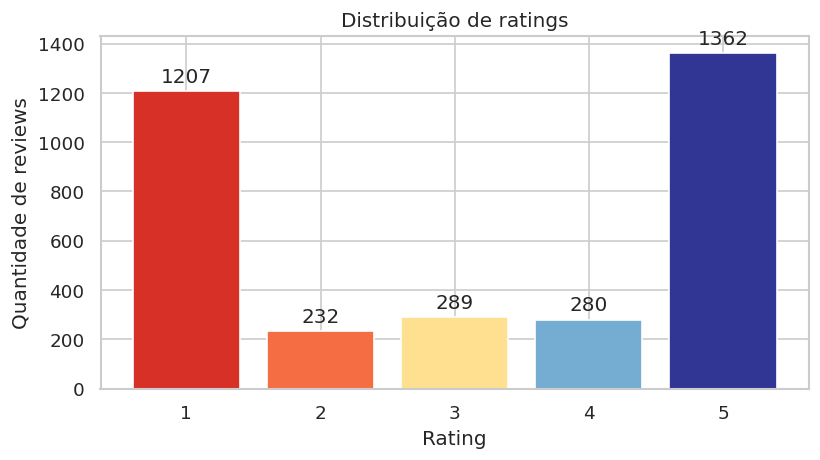

rating
1    1207
2     232
3     289
4     280
5    1362
Name: count, dtype: int64

rating
1    35.816024
2     6.884273
3     8.575668
4     8.308605
5    40.415430
Name: count, dtype: float64


In [6]:
rating_counts = df["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
              color=["#d73027","#f46d43","#fee090","#74add1","#313695"])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Rating")
ax.set_ylabel("Quantidade de reviews")
ax.set_title("Distribuição de ratings")
plt.tight_layout()
plt.savefig("../reports/figures/01_distribuicao_rating.png")
plt.show()

print(rating_counts)
print()
print(rating_counts / len(df) * 100)


## 5. Definição das classes de sentimento

Mapeamento adotado:

| Rating | Sentimento |
|--------|-----------|
| 1 – 2  | negativo  |
| 3      | neutro    |
| 4 – 5  | positivo  |

> Decisão: manter 3 classes na EDA. Avaliar se sera necessario incluir neutro em negativo ou positivo para simplificar em binário ou remove-lo.


In [7]:
# Mapeamento em 3 classes — mantido após análise do vocabulário por classe:
# neutro tem tokens ("good", "nice", "money") distintos do negativo ("bad", "worst", "cold")
# Colapsar neutro em negativo contaminaria o label negativo com tokens positivos.
# Decisão revisada: manter 3 classes e avaliar separação no notebook 03.
#
# Positivo: rating 4-5
# Neutro:   rating 3
# Negativo: rating 1-2

def rating_to_sentiment(r):
    if r >= 4:
        return "positivo"
    elif r == 3:
        return "neutro"
    else:
        return "negativo"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

counts = df["sentiment"].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1))


sentiment
positivo    1642
negativo    1439
neutro       289
Name: count, dtype: int64

sentiment
positivo    48.7
negativo    42.7
neutro       8.6
Name: count, dtype: float64


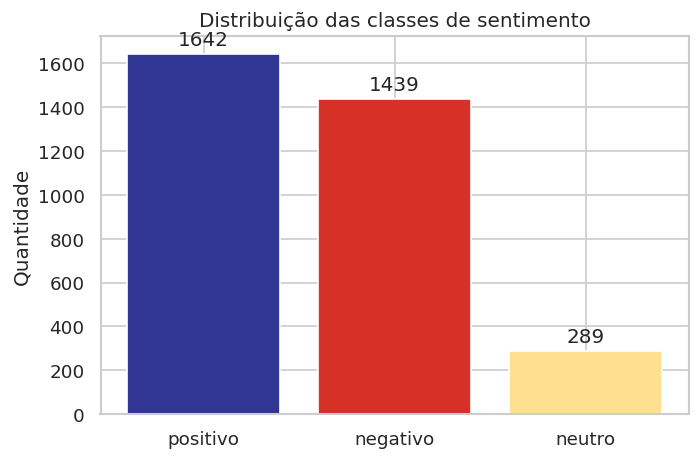

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = {"positivo": "#313695", "neutro": "#fee090", "negativo": "#d73027"}
bars = ax.bar(counts.index, counts.values,
              color=[colors[s] for s in counts.index])
ax.bar_label(bars, padding=3)
ax.set_title("Distribuição das classes de sentimento")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig("../reports/figures/01_distribuicao_sentimento.png")
plt.show()


## 6. Análise do tamanho das reviews

In [9]:
df["n_chars"] = df["review"].str.len()
df["n_words"] = df["review"].str.split().str.len()

print("=== Caracteres por review ===")
print(df["n_chars"].describe().round(1))
print()
print("=== Palavras por review ===")
print(df["n_words"].describe().round(1))


=== Caracteres por review ===
count    3370.0
mean       72.0
std        71.1
min         9.0
25%        28.0
50%        51.0
75%        91.0
max       788.0
Name: n_chars, dtype: float64

=== Palavras por review ===
count    3370.0
mean       12.9
std        12.5
min         3.0
25%         5.0
50%         9.0
75%        16.0
max       150.0
Name: n_words, dtype: float64


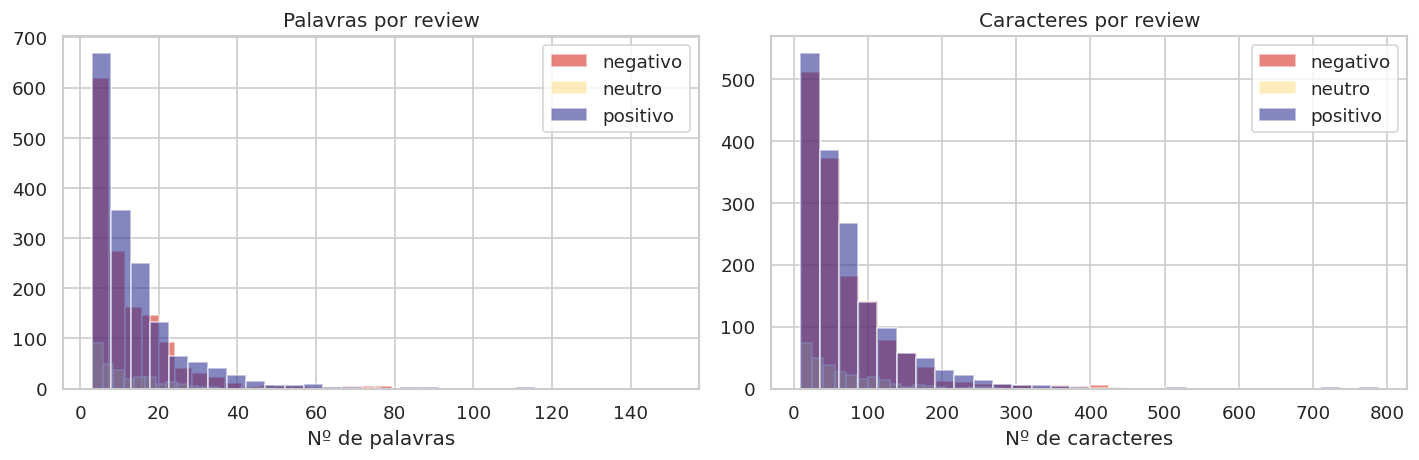

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sent, grp in df.groupby("sentiment"):
    axes[0].hist(grp["n_words"], bins=30, alpha=0.6, label=sent,
                 color=colors[sent])
    axes[1].hist(grp["n_chars"], bins=30, alpha=0.6, label=sent,
                 color=colors[sent])

axes[0].set_title("Palavras por review")
axes[0].set_xlabel("Nº de palavras")
axes[0].legend()
axes[1].set_title("Caracteres por review")
axes[1].set_xlabel("Nº de caracteres")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/01_tamanho_reviews.png")
plt.show()


## 7. Verificação de idioma (amostra)

In [11]:
# Detectar Hinglish via proporção de tokens reconhecidos como inglês
# NLTK words (~235k palavras) — muito mais robusto que lista de 13 palavras fixas
nltk.download("words", quiet=True)
from nltk.corpus import words as nltk_words

ENGLISH_VOCAB = set(w.lower() for w in nltk_words.words())


def eh_hinglish(texto):
    """True se < 50% dos tokens forem palavras inglesas reconhecidas."""
    tokens = re.sub(r"[^a-z\s]", "", str(texto).lower()).split()
    if not tokens:
        return True
    pct_en = sum(1 for t in tokens if t in ENGLISH_VOCAB) / len(tokens)
    return pct_en < 0.50


df["hinglish"] = df["review"].apply(eh_hinglish)
hinglish_df = df[df["hinglish"]]
print(f"Reviews Hinglish (< 50% tokens ingleses): {len(hinglish_df)} ({len(hinglish_df)/len(df)*100:.1f}%)")
print()
print(hinglish_df["review"].head(10).to_string())

Reviews Hinglish (< 50% tokens ingleses): 209 (6.2%)

87                                    paav kio nhi bheja
102    spoon nahi diya hai  order k sath spoon dena c...
134          bhai ishse ghatiya kuchh nahi khaya aaj tak
148    🥄 spoon nhi tha yahi hai buss<br/>wrna or sab ...
149              masala pav aaya hai nay tu kisa star do
177                                      जादा ठिक नही था
178                                         अच्छा नही था
196    🙏🏻જય સ્વામિનારાયણ<br/><br/>બહુ સરસ કોલ્ડ કોકો ...
231    exta kaju ka 40 piya lekin 10 rupey ke bheje 🤣...
263    sab ghuli thi abhi kya kare ek dam bekar item ...


In [12]:
pct = len(hinglish_df) / len(df) * 100
print(f"Proporção Hinglish: {len(hinglish_df)}/{len(df)} ({pct:.1f}%)")
print()
print(hinglish_df["sentiment"].value_counts())

Proporção Hinglish: 209/3370 (6.2%)

sentiment
positivo    95
negativo    93
neutro      21
Name: count, dtype: int64


## 8. Palavras mais frequentes por sentimento

In [13]:
def tokenizar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z\s]", "", texto)
    tokens = texto.split()
    return [t for t in tokens if t not in STOP_EN and len(t) > 2]

for sent in ["positivo", "neutro", "negativo"]:
    subset = df[df["sentiment"] == sent]["review"]
    tokens = []
    for review in subset:
        tokens.extend(tokenizar(review))
    top = Counter(tokens).most_common(15)
    print(f"=== {sent.upper()} — top 15 palavras ===")
    for palavra, freq in top:
        print(f"  {palavra}: {freq}")
    print()


=== POSITIVO — top 15 palavras ===
  food: 352
  good: 329
  taste: 280
  order: 196
  bad: 149
  quality: 129
  delivery: 116
  quantity: 106
  like: 93
  ordered: 91
  service: 89
  time: 88
  less: 82
  restaurant: 80
  also: 75

=== NEUTRO — top 15 palavras ===
  food: 55
  taste: 53
  good: 48
  bad: 43
  order: 32
  delivery: 26
  money: 26
  restaurant: 21
  quality: 21
  best: 20
  service: 17
  also: 16
  quantity: 15
  worst: 15
  please: 13

=== NEGATIVO — top 15 palavras ===
  good: 258
  food: 254
  taste: 224
  order: 181
  bad: 126
  quality: 107
  delivery: 103
  like: 99
  test: 93
  quantity: 90
  restaurant: 89
  ordered: 79
  service: 77
  worst: 76
  time: 75



### Alerta: palavras negativas na classe positivo

`bad` aparece **149×** na classe **positivo** e `good` **258×** na classe **negativo**. Dois fenômenos explicam isso:

1. **Negação não capturada:** `"not bad"` (= positivo) é tokenizado como `bad` — o bag-of-words perde o contexto da negação.
2. **Contraste intra-review:** `"service was bad but food was amazing"` (rating 4) — review positiva com palavra negativa dentro.

**Implicação para o notebook 03:** TF-IDF com unigramas puro cometerá erros sistemáticos aqui. Estratégias a testar:
- `ngram_range=(1, 2)` — captura `not bad`, `not good`, `very bad`, `so good`
- Análise de falsos positivos/negativos focada em reviews com `bad`/`good` fora do contexto esperado


## 9. Word clouds por sentimento

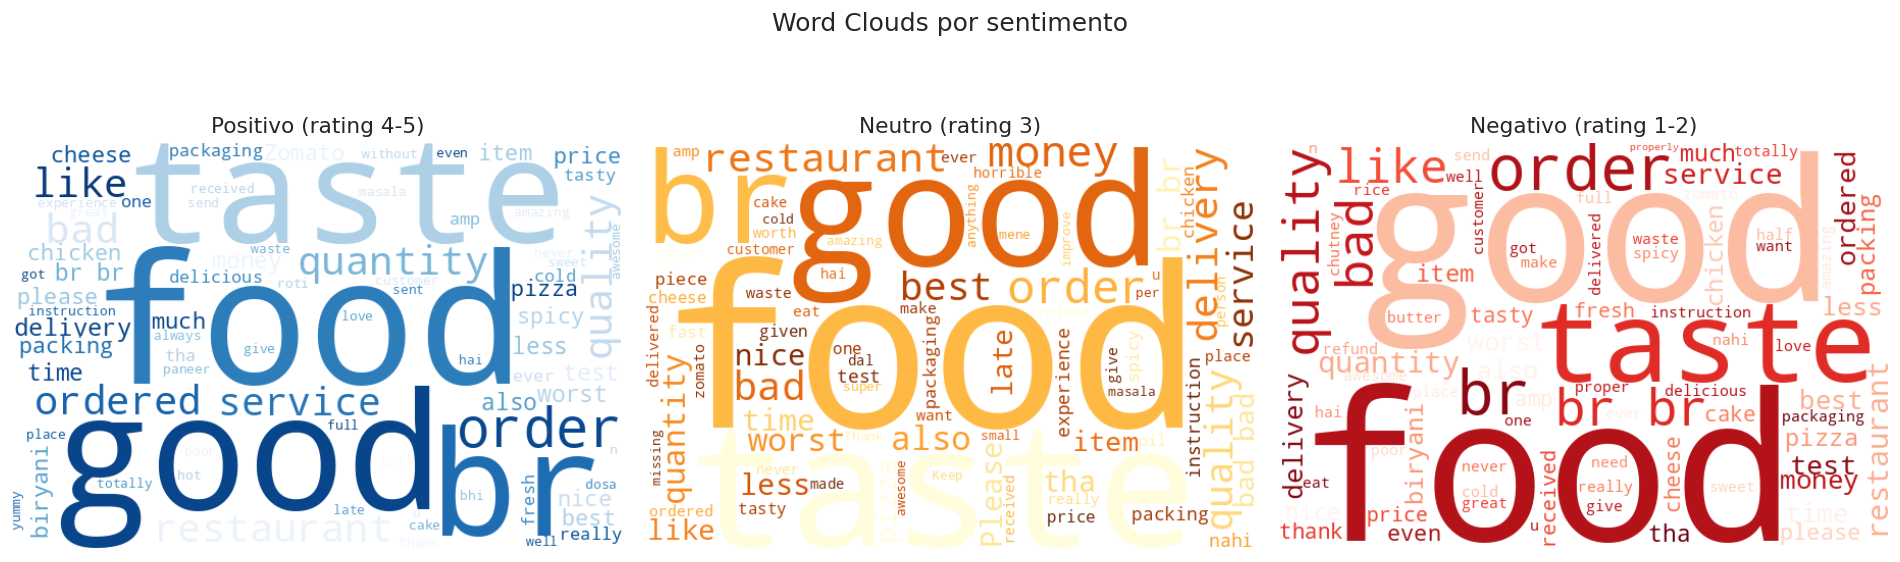

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sentimentos = ["positivo", "neutro", "negativo"]
titulos = ["Positivo (rating 4-5)", "Neutro (rating 3)", "Negativo (rating 1-2)"]
cmaps = ["Blues", "YlOrBr", "Reds"]

for ax, sent, titulo, cmap in zip(axes, sentimentos, titulos, cmaps):
    texto_concat = " ".join(
        df[df["sentiment"] == sent]["review"].astype(str)
    )
    wc = WordCloud(
        width=600, height=400,
        stopwords=STOP_EN,
        colormap=cmap,
        background_color="white",
        max_words=80
    ).generate(texto_concat)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(titulo, fontsize=13)

plt.suptitle("Word Clouds por sentimento", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/01_wordclouds_sentimento.png", bbox_inches="tight")
plt.show()


## 10. Conclusões e decisões para o pré-processamento

### Achados da EDA

| Item | Valor |
|---|---|
| Shape original | 5.479 linhas |
| Após `dropna` (1 NaN em `review`) | 5.478 linhas |
| Camada 1 — duplicatas exatas | −860 → 4.618 linhas |
| Camada 2 — ratings conflitantes | −668 (280 textos únicos) → 3.950 linhas |
| Camada 3 — reviews ≤ 2 palavras | −580 → 3.370 linhas |
| **Shape final** | **3.370 linhas (61,5% do original)** |
| Distribuição final | positivo 48,7% / neutro 8,6% / negativo 42,7% |
| Tamanho médio das reviews | ~13 palavras (mediana: 9) |
| Reviews Hinglish (NLTK words, limiar 50%) | 209 (6,2%) — reviews com <50% tokens não-ingleses |

> **Nota sobre Hinglish:** a heurística NLTK identifica reviews onde a maioria dos tokens não é reconhecida como inglês. Reviews com palavras hindi soltas entre texto inglês passam pelo filtro (ex: *"best biryani ever zabardast"* tem tokens ingleses suficientes). A proporção de reviews com qualquer mistura hindi é maior que 6,2%, mas a decisão de manter todas permanece inalterada.

### Decisões tomadas

- **Classes: 3 classes mantidas** (positivo / neutro / negativo)
  - Vocabulário do neutro é distinto do negativo, colapsar contaminaria os labels
  - Se F1(neutro) < 0,45 no notebook 03 → reavaliar colapso com dados na mão
- **Idioma:** Hinglish mantido. Tokens são consistentes; filtrar perderia parcela significativa dos dados
- **Camada 2 foi crítica:** `good` aparecia com ratings 1–5, ruído semântico puro
- **Alerta de negação:** `bad` aparece 149× no positivo, testar `ngram_range=(1, 2)` no notebook 03

### Próximo passo — Notebook 02

- lowercase, remoção de pontuação e stopwords (NLTK english)
- Avaliar lemmatização (custo vs ganho no dataset de 3.370 linhas)
- Train/test split **antes** do TF-IDF fit
- `max_features` TF-IDF: começar com 5.000; `ngram_range=(1, 2)` como variante a comparar


## 11. Salvar dataset processado

In [15]:
import os

os.makedirs("../data/processed", exist_ok=True)
out_path = "../data/processed/zomato_reviews_clean.csv"
df[["rating", "review", "sentiment"]].to_csv(out_path, index=False)

print(f"Salvo em: {out_path}")
print(f"Shape: {df[['rating','review','sentiment']].shape}")
print()
print(df[["rating", "review", "sentiment"]].head(5).to_string())


Salvo em: ../data/processed/zomato_reviews_clean.csv
Shape: (3370, 3)

   rating                                                                                                    review sentiment
1       5  best biryani , so supportive staff of outlet , personalize my order on call as I say. full Paisa vasool   positivo
2       4                                                            delivery boy was very decent and supportive.👌👍  positivo
3       1                               worst biryani i have tasted in my life, half of the biryani is in dustbin.   negativo
4       5               all food is good and tasty . will order again and lots more to explore in bawarchi's menu.   positivo
5       5                                             shandar zabardast zindabad .. good going bawarchi keep it up   positivo
